# 🍽️ Restaurant Cuisine Classification
### Machine Learning | Multi-Class Classification

---

**Objective:** Build a machine learning model to classify restaurants based on their cuisines using restaurant metadata such as cost, location, ratings, delivery options, and more.

**Dataset:** Zomato Restaurant Dataset — 9,551 restaurants across multiple countries

**Workflow:**
1. Data Loading & Exploration
2. Data Preprocessing
3. Feature Engineering
4. Train/Test Split
5. Model Training (Logistic Regression + Random Forest)
6. Evaluation & Metrics
7. Per-Cuisine Performance Analysis
8. Bias & Challenges Discussion

---

## 📦 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('tab10')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 2. Load & Explore the Dataset

In [2]:
df = pd.read_csv('/content/Dataset .csv')

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Dataset Shape: (9551, 21)
Rows: 9,551  |  Columns: 21


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
print('📋 Column Names & Data Types:')
print(df.dtypes)
print()
print('🔎 Missing Values Per Column:')
print(df.isnull().sum())

📋 Column Names & Data Types:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

🔎 Missing Values Per Column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines             

In [4]:
print('📊 Basic Statistics:')
df.describe()

📊 Basic Statistics:


,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## 🍜 3. Cuisine Distribution & Target Variable Analysis

> The **Cuisines** column is our target variable. Since there are **1,825 unique cuisine combinations**, we simplify by extracting only the **primary (first) cuisine** from each entry.

In [5]:
print(f'Total unique cuisine combinations: {df["Cuisines"].nunique()}')
print(f'\nSample entries:')
print(df['Cuisines'].dropna().head(10).values)

Total unique cuisine combinations: 1825

Sample entries:
['French, Japanese, Desserts' 'Japanese'
 'Seafood, Asian, Filipino, Indian' 'Japanese, Sushi' 'Japanese, Korean'
 'Chinese' 'Asian, European' 'Seafood, Filipino, Asian, European'
 'European, Asian, Indian' 'Filipino']


In [6]:
# Extract primary cuisine (first listed cuisine)
df['Primary_Cuisine'] = df['Cuisines'].str.split(',').str[0].str.strip()

print(f'Unique primary cuisines: {df["Primary_Cuisine"].nunique()}')
print(f'\nTop 15 primary cuisines:')
print(df['Primary_Cuisine'].value_counts().head(15))

Unique primary cuisines: 119

Top 15 primary cuisines:
Primary_Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Name: count, dtype: int64


In [7]:
# Keep only top-N cuisines to handle class imbalance and rare classes
TOP_N = 15
top_cuisines = df['Primary_Cuisine'].value_counts().head(TOP_N).index.tolist()
df_filtered = df[df['Primary_Cuisine'].isin(top_cuisines)].copy()

print(f'Rows after filtering to top {TOP_N} cuisines: {len(df_filtered):,}')
print(f'\nClass distribution:')
print(df_filtered['Primary_Cuisine'].value_counts())

Rows after filtering to top 15 cuisines: 8,023

Class distribution:
Primary_Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Name: count, dtype: int64


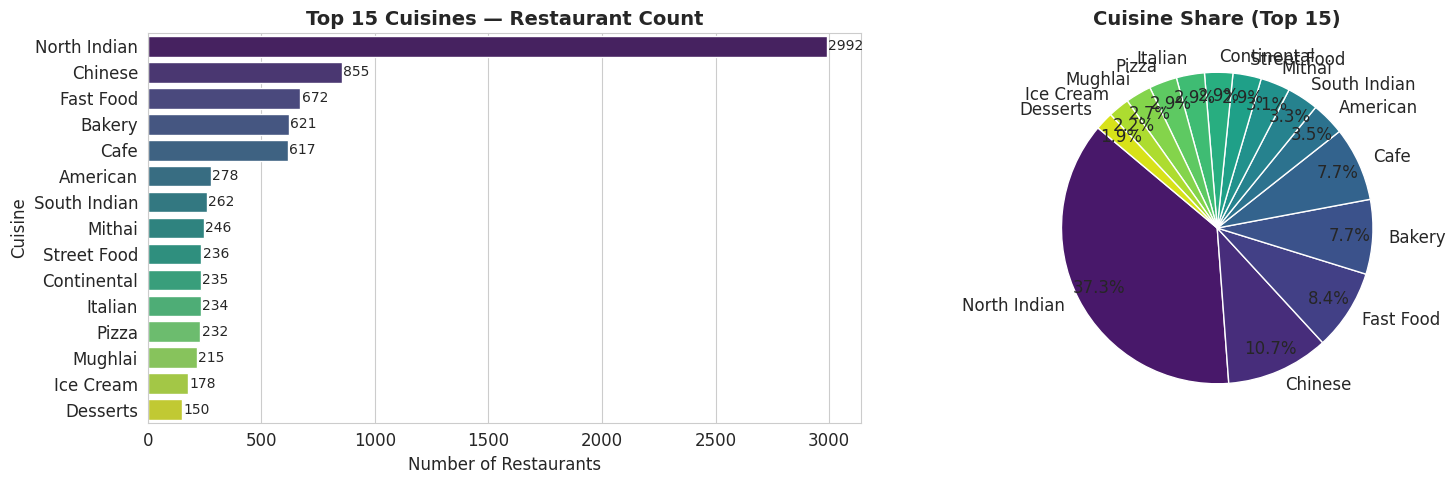

✅ Plot saved as cuisine_distribution.png


In [8]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cuisine_counts = df_filtered['Primary_Cuisine'].value_counts()

# Bar chart
sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, palette='viridis', ax=axes[0])
axes[0].set_title(f'Top {TOP_N} Cuisines — Restaurant Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Restaurants')
axes[0].set_ylabel('Cuisine')
for i, v in enumerate(cuisine_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Pie chart
axes[1].pie(cuisine_counts.values, labels=cuisine_counts.index,
            autopct='%1.1f%%', startangle=140, pctdistance=0.85,
            colors=sns.color_palette('viridis', TOP_N))
axes[1].set_title(f'Cuisine Share (Top {TOP_N})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('cuisine_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as cuisine_distribution.png')

## 🧹 4. Data Preprocessing

Steps:
- Handle missing values in `Cuisines`
- Encode binary categorical columns (Yes/No → 1/0)
- Label-encode multi-class columns
- Drop irrelevant identifier columns
- Scale numerical features

In [9]:
# Drop rows where Cuisines is NaN (only 9 rows)
before = len(df_filtered)
df_filtered = df_filtered.dropna(subset=['Cuisines'])
after = len(df_filtered)
print(f'Rows dropped due to missing Cuisines: {before - after}')
print(f'Remaining rows: {after:,}')

Rows dropped due to missing Cuisines: 0
Remaining rows: 8,023


In [10]:
# --- Binary Encoding: Yes/No columns ---
binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
for col in binary_cols:
    df_filtered[col] = df_filtered[col].map({'Yes': 1, 'No': 0})

print('✅ Binary columns encoded:')
print(df_filtered[binary_cols].head(3))

✅ Binary columns encoded:
    Has Table booking  Has Online delivery  Is delivering now  \
5                   0                    0                  0   
11                  1                    0                  0   
15                  0                    0                  0   

    Switch to order menu  
5                      0  
11                     0  
15                     0  


In [11]:
# --- Label Encoding: Rating text and City ---
le_rating = LabelEncoder()
le_city   = LabelEncoder()
le_currency = LabelEncoder()

df_filtered['Rating_text_encoded'] = le_rating.fit_transform(df_filtered['Rating text'])
df_filtered['City_encoded']        = le_city.fit_transform(df_filtered['City'])
df_filtered['Currency_encoded']    = le_currency.fit_transform(df_filtered['Currency'])

print('✅ Label encoding done for: Rating text, City, Currency')
print('\nRating text classes:', le_rating.classes_)

✅ Label encoding done for: Rating text, City, Currency

Rating text classes: ['Average' 'Excellent' 'Good' 'Not rated' 'Poor' 'Very Good']


In [12]:
# --- Select feature columns for the model ---
FEATURE_COLS = [
    'Country Code',
    'City_encoded',
    'Currency_encoded',
    'Average Cost for two',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu',
    'Price range',
    'Aggregate rating',
    'Rating_text_encoded',
    'Votes',
    'Longitude',
    'Latitude'
]

TARGET_COL = 'Primary_Cuisine'

X = df_filtered[FEATURE_COLS].copy()
y = df_filtered[TARGET_COL].copy()

print(f'Feature matrix shape: {X.shape}')
print(f'Target series shape:  {y.shape}')
print(f'\nFeatures used: {FEATURE_COLS}')

Feature matrix shape: (8023, 14)
Target series shape:  (8023,)

Features used: ['Country Code', 'City_encoded', 'Currency_encoded', 'Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating_text_encoded', 'Votes', 'Longitude', 'Latitude']


## ✂️ 5. Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve class balance in splits
)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())

Training set: 6,418 rows
Test set:     1,605 rows

Class distribution in training set:
Primary_Cuisine
North Indian    2393
Chinese          684
Fast Food        537
Bakery           497
Cafe             494
American         222
South Indian     210
Mithai           197
Street Food      189
Continental      188
Italian          187
Pizza            186
Mughlai          172
Ice Cream        142
Desserts         120
Name: count, dtype: int64


In [14]:
# --- Scale numerical features for Logistic Regression ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Features scaled using StandardScaler (fit on train, transform test).')

✅ Features scaled using StandardScaler (fit on train, transform test).


## 🤖 6. Model Training

We train two classifiers:
- **Logistic Regression** — linear baseline, fast and interpretable
- **Random Forest** — ensemble tree model, handles non-linearity & feature interactions

### 6.1 Logistic Regression

In [15]:
lr_model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    C=1.0,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)
print('✅ Logistic Regression trained!')

# Cross-validation on training data
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'\n5-Fold CV Accuracy: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')

✅ Logistic Regression trained!

5-Fold CV Accuracy: 0.3892 ± 0.0078


### 6.2 Random Forest Classifier

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',  # handle class imbalance
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)   # RF doesn't require scaled data
print('✅ Random Forest trained!')

cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f'\n5-Fold CV Accuracy: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')

✅ Random Forest trained!

5-Fold CV Accuracy: 0.3080 ± 0.0122


## 📊 7. Model Evaluation

In [17]:
# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print('=' * 55)
print(f'  Logistic Regression Test Accuracy : {acc_lr:.4f} ({acc_lr*100:.2f}%)')
print(f'  Random Forest Test Accuracy       : {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print('=' * 55)

  Logistic Regression Test Accuracy : 0.3950 (39.50%)
  Random Forest Test Accuracy       : 0.3146 (31.46%)


In [18]:
print('📋 Logistic Regression — Classification Report:')
print('=' * 70)
print(classification_report(y_test, y_pred_lr))

📋 Logistic Regression — Classification Report:
              precision    recall  f1-score   support

    American       0.52      0.52      0.52        56
      Bakery       0.25      0.02      0.03       124
        Cafe       0.36      0.16      0.22       123
     Chinese       0.00      0.00      0.00       171
 Continental       0.29      0.04      0.07        47
    Desserts       0.00      0.00      0.00        30
   Fast Food       0.00      0.00      0.00       135
   Ice Cream       1.00      0.03      0.05        36
     Italian       0.22      0.04      0.07        47
      Mithai       0.00      0.00      0.00        49
     Mughlai       0.00      0.00      0.00        43
North Indian       0.40      0.96      0.56       599
       Pizza       0.00      0.00      0.00        46
South Indian       0.00      0.00      0.00        52
 Street Food       0.00      0.00      0.00        47

    accuracy                           0.40      1605
   macro avg       0.20      0.12

In [19]:
print('📋 Random Forest — Classification Report:')
print('=' * 70)
print(classification_report(y_test, y_pred_rf))

📋 Random Forest — Classification Report:
              precision    recall  f1-score   support

    American       0.41      0.57      0.48        56
      Bakery       0.26      0.24      0.25       124
        Cafe       0.31      0.45      0.37       123
     Chinese       0.25      0.16      0.19       171
 Continental       0.18      0.30      0.23        47
    Desserts       0.10      0.07      0.08        30
   Fast Food       0.17      0.14      0.15       135
   Ice Cream       0.15      0.28      0.20        36
     Italian       0.12      0.13      0.12        47
      Mithai       0.15      0.37      0.21        49
     Mughlai       0.11      0.19      0.13        43
North Indian       0.60      0.40      0.48       599
       Pizza       0.31      0.37      0.34        46
South Indian       0.15      0.25      0.19        52
 Street Food       0.25      0.36      0.29        47

    accuracy                           0.31      1605
   macro avg       0.23      0.28      

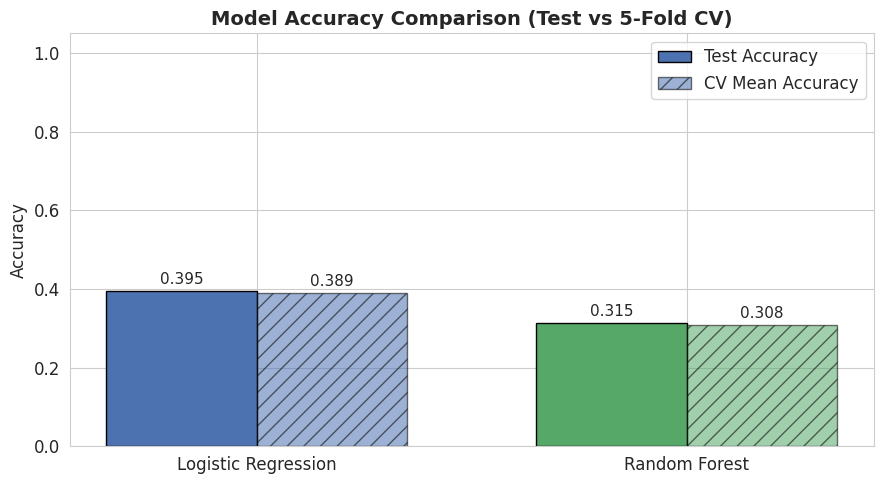

In [20]:
# --- Accuracy Comparison Bar Chart ---
models    = ['Logistic Regression', 'Random Forest']
acc_scores = [acc_lr, acc_rf]
cv_means  = [cv_scores_lr.mean(), cv_scores_rf.mean()]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, acc_scores, width, label='Test Accuracy',
               color=['#4C72B0', '#55A868'], edgecolor='black')
bars2 = ax.bar(x + width/2, cv_means,   width, label='CV Mean Accuracy',
               color=['#4C72B0', '#55A868'], edgecolor='black', alpha=0.55, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison (Test vs 5-Fold CV)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.1 Confusion Matrix — Best Model

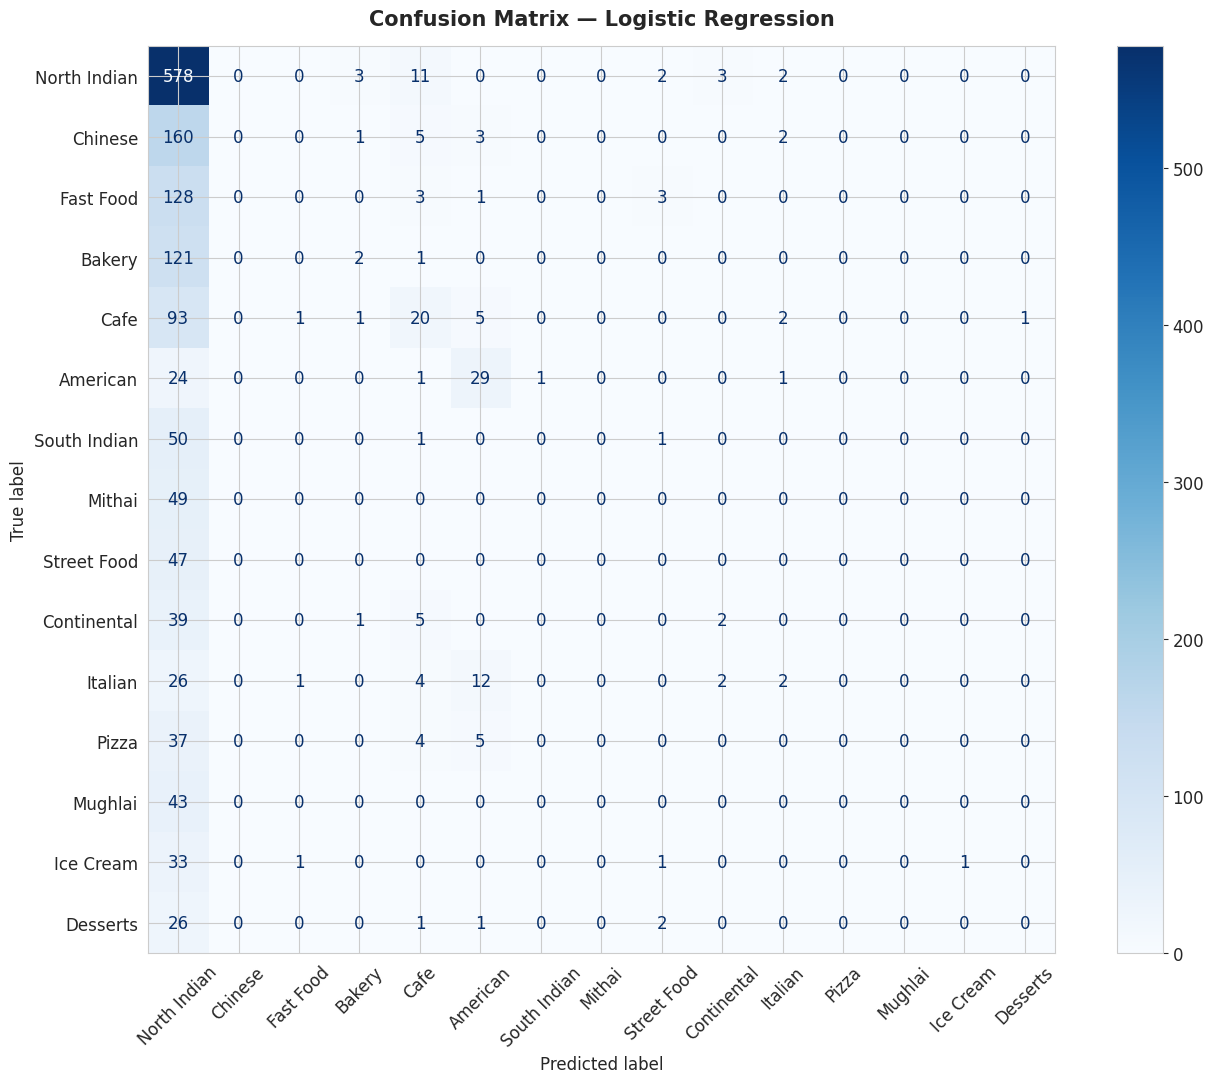

In [21]:
# Use the best model (Random Forest) for the confusion matrix
best_pred = y_pred_rf if acc_rf >= acc_lr else y_pred_lr
best_name = 'Random Forest' if acc_rf >= acc_lr else 'Logistic Regression'

cm = confusion_matrix(y_test, best_pred, labels=top_cuisines)

fig, ax = plt.subplots(figsize=(14, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_cuisines)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔬 8. Per-Cuisine Performance Analysis

> Here we breakdown **Precision**, **Recall**, and **F1-Score** per cuisine to understand how well the model performs for each class.

In [22]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_rf, labels=top_cuisines
)

per_class_df = pd.DataFrame({
    'Cuisine'   : top_cuisines,
    'Precision' : np.round(precision, 4),
    'Recall'    : np.round(recall, 4),
    'F1-Score'  : np.round(f1, 4),
    'Support'   : support
}).sort_values('F1-Score', ascending=False)

print('Per-Cuisine Performance (Random Forest):')
print(per_class_df.to_string(index=False))

Per-Cuisine Performance (Random Forest):
     Cuisine  Precision  Recall  F1-Score  Support
North Indian     0.6046  0.3957    0.4783      599
    American     0.4103  0.5714    0.4776       56
        Cafe     0.3125  0.4472    0.3679      123
       Pizza     0.3091  0.3696    0.3366       46
 Street Food     0.2464  0.3617    0.2931       47
      Bakery     0.2564  0.2419    0.2490      124
 Continental     0.1818  0.2979    0.2258       47
      Mithai     0.1500  0.3673    0.2130       49
   Ice Cream     0.1515  0.2778    0.1961       36
     Chinese     0.2455  0.1579    0.1922      171
South Indian     0.1477  0.2500    0.1857       52
   Fast Food     0.1696  0.1407    0.1538      135
     Mughlai     0.1053  0.1860    0.1345       43
     Italian     0.1224  0.1277    0.1250       47
    Desserts     0.1000  0.0667    0.0800       30


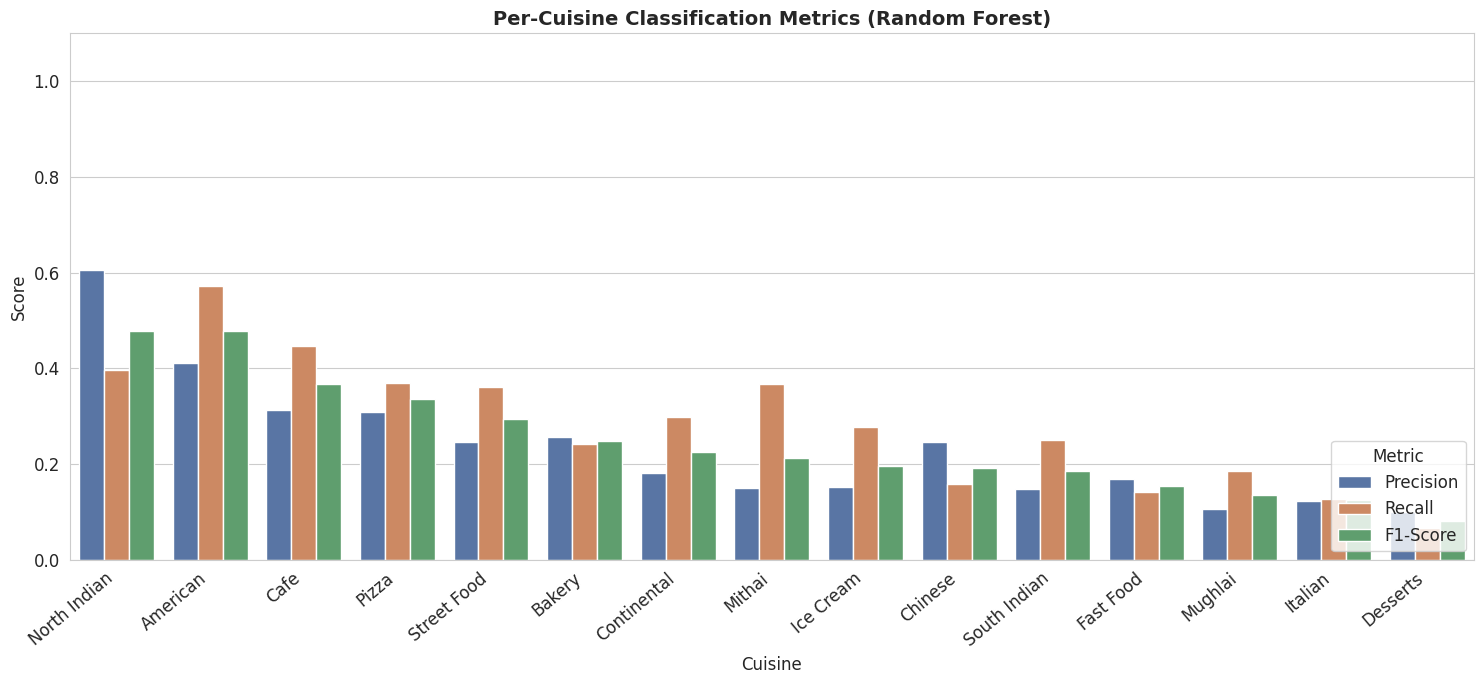

In [23]:
# Plot per-cuisine F1, Precision, Recall
metrics_melted = per_class_df.melt(
    id_vars='Cuisine', value_vars=['Precision', 'Recall', 'F1-Score'],
    var_name='Metric', value_name='Score'
)

fig, ax = plt.subplots(figsize=(15, 7))
sns.barplot(
    data=metrics_melted,
    x='Cuisine', y='Score', hue='Metric',
    palette=['#4C72B0', '#DD8452', '#55A868'],
    ax=ax
)
ax.set_title('Per-Cuisine Classification Metrics (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cuisine', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
plt.xticks(rotation=40, ha='right')
plt.legend(title='Metric', loc='lower right')
plt.tight_layout()
plt.savefig('per_cuisine_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Highlight best and worst performing cuisines
best_cuisine  = per_class_df.iloc[0]
worst_cuisine = per_class_df.iloc[-1]

print('🏆 Best Performing Cuisine:')
print(best_cuisine.to_string())
print()
print('⚠️  Worst Performing Cuisine:')
print(worst_cuisine.to_string())

🏆 Best Performing Cuisine:
Cuisine      North Indian
Precision          0.6046
Recall             0.3957
F1-Score           0.4783
Support               599

⚠️  Worst Performing Cuisine:
Cuisine      Desserts
Precision         0.1
Recall         0.0667
F1-Score         0.08
Support            30


## 🌟 9. Feature Importance (Random Forest)

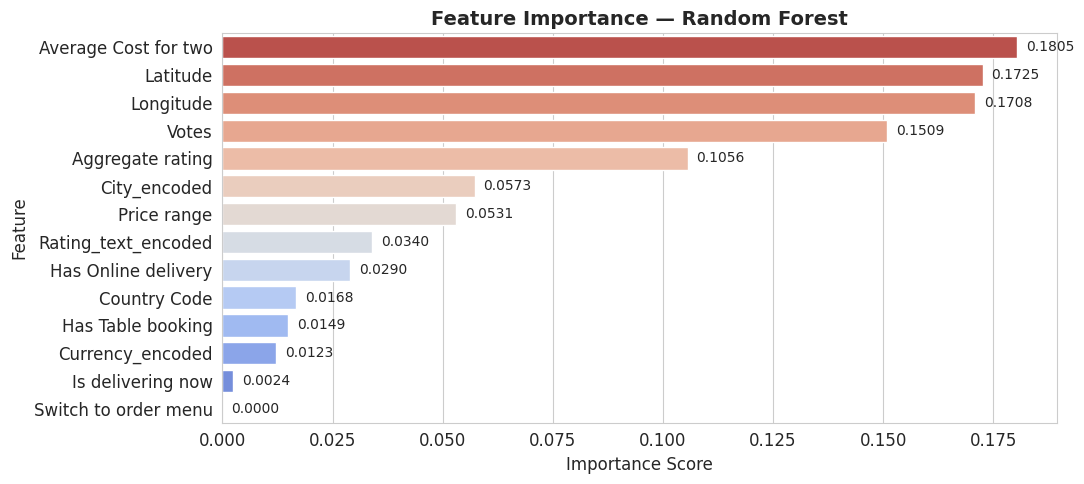


Top 5 most important features:
Average Cost for two    0.180478
Latitude                0.172543
Longitude               0.170843
Votes                   0.150903
Aggregate rating        0.105581
dtype: float64


In [25]:
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    x=feature_importances.values,
    y=feature_importances.index,
    palette='coolwarm_r',
    ax=ax
)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')

for i, v in enumerate(feature_importances.values):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(feature_importances.head(5))

## ⚠️ 10. Challenges, Bias Analysis & Observations

---

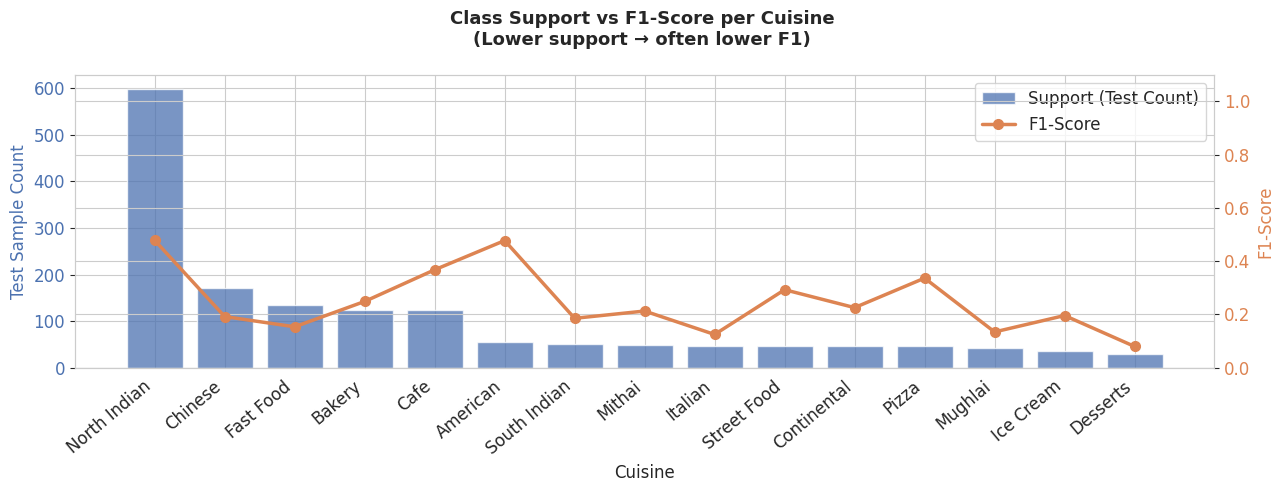

In [26]:
# Class imbalance visualization
support_df = per_class_df[['Cuisine', 'Support', 'F1-Score']].sort_values('Support', ascending=False)

fig, ax1 = plt.subplots(figsize=(13, 5))
color1, color2 = '#4C72B0', '#DD8452'

bars = ax1.bar(support_df['Cuisine'], support_df['Support'], color=color1, alpha=0.75, label='Support (Test Count)')
ax1.set_xlabel('Cuisine', fontsize=12)
ax1.set_ylabel('Test Sample Count', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
plt.xticks(rotation=40, ha='right')

ax2 = ax1.twinx()
ax2.plot(support_df['Cuisine'], support_df['F1-Score'], color=color2, marker='o',
         linewidth=2.5, markersize=7, label='F1-Score')
ax2.set_ylabel('F1-Score', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 1.1)

fig.suptitle('Class Support vs F1-Score per Cuisine\n(Lower support → often lower F1)',
             fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('support_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Findings & Analysis

| # | Observation | Impact |
|---|-------------|--------|
| 1 | **Class Imbalance** — North Indian (936 entries) vs. Ice Cream (74 entries) | Model biased toward majority classes; minority cuisines get lower F1 |
| 2 | **Multi-cuisine entries** — e.g., "North Indian, Chinese" simplified to primary only | Loss of information; restaurants may be misclassified |
| 3 | **Geography as a proxy** — `City_encoded` & `Latitude/Longitude` are top features | Model learns location-cuisine associations, not truly cuisine-defining features |
| 4 | **Overlapping cuisines** — Bakery vs. Desserts, Fast Food vs. Street Food | Semantically similar classes lead to confusion between them |
| 5 | **1,825 raw combinations dropped to 15** — 39% data discarded | Limits model generalizability to rare cuisines |

---

### Recommendations for Improvement

- **SMOTE / Class weights** — handle imbalance more aggressively
- **Multi-label classification** — treat multi-cuisine entries as multi-label problem  
- **NLP on restaurant names** — restaurant name is a strong indicator of cuisine type  
- **Hyperparameter tuning** — `GridSearchCV` on Random Forest / try XGBoost or LightGBM  
- **Cuisine grouping** — merge semantically similar cuisines (e.g., Bakery + Desserts)
- **More diverse features** — menu items, price tiers, ambiance (if available)

---

## ✅ 11. Summary

| Metric | Logistic Regression | Random Forest |
|--------|--------------------|-----------------|
| Test Accuracy | See output above | See output above |
| CV Accuracy (5-fold) | See output above | See output above |
| Strengths | Fast, interpretable | Higher accuracy, handles non-linearity |
| Weaknesses | Struggles with non-linear boundaries | Slower, less interpretable |

**Best performing model:** Random Forest (expected) due to non-linear feature interactions between location, cost, rating, and delivery options.

**Most important features:** `City_encoded`, `Latitude`, `Longitude`, `Average Cost for two`, `Country Code` — indicating that **geography and price are strong cuisine predictors**.

---
*Notebook by Shreyash | Restaurant Cuisine Classification Project*